In [29]:
# =============================================================================
# classical_reservoir.ipynb — Echo State Network Baseline
# =============================================================================
#
# This notebook implements two Classical Reservoir Computing (Echo State
# Network) baselines for the paper:
#   "Quantum Reservoir Computing for Realized Volatility Forecasting"
#   (arXiv:2505.13933)
#
# OVERVIEW:
# A classical reservoir (Echo State Network / ESN) is a recurrent neural
# network where the recurrent weights are FIXED (randomly initialized)
# and only the output weights are trained. This is analogous to the
# quantum reservoir, where the Hamiltonian is fixed and only the readout
# is trained via ridge regression.
#
# Two model variants:
#   1. CRL  (RC)  — Uses only RV as input, N=50 reservoir neurons
#   2. CRLX (RCX) — Uses all 11 features as input, N=20 reservoir neurons
#
# RESERVOIR DYNAMICS (paper Eq. 4-5):
#   h_t = (1 - alpha) * h_{t-1} + F(W_r * h_{t-1} + W_in * x_t + b)
#   y_t = W_out * h_t
#
#   Where:
#     h_t      = reservoir hidden state at time t
#     alpha    = leak rate (0.6) — controls memory decay
#     W_r      = reservoir weight matrix (random, fixed, spectral radius 0.9)
#     W_in     = input weight matrix (random, fixed, scaling 0.1)
#     F()      = activation function (tanh)
#     W_out    = output weights (trained via ridge regression)
#
# OUTPUTS:
#   - Classical_Reservoir_learning/best_CRL(50)_predictions.csv
#   - Classical_Reservoir_learning/best_CRLX(20)_predictions.csv
#
# PREREQUISITES:
#   Run `python preprocess.py` first to generate dff.csv and Data_raw.csv
#
# Paper reference: Section III.B, Appendix D (hyperparameter selection)
# =============================================================================

import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import os

# Limit OpenMP threads to prevent thread-spawning overhead in reservoir runs
os.environ["OMP_NUM_THREADS"] = "1"

# Create output directory for reservoir prediction files
os.makedirs("Classical_Reservoir_learning", exist_ok=True)

# Set random seed for partial reproducibility of reservoir initialization
# Note: reservoirpy 0.4+ replaced rpy.verbosity() with rpy.set_seed()
rpy.set_seed(0)


In [30]:
# =============================================================================
# Load Data
# =============================================================================
# Load the differenced dataset and add the STR column from raw data.
# Same data preparation as LSTM.ipynb — see that notebook for details.
dff = pd.read_csv("dff.csv", header=0, index_col=0)
dff1 = pd.read_csv("Data_raw.csv", header=0, index_col=0)
dff["STR"] = dff1["STR"]  # Add Short-Term Reversal factor (stationary, not differenced)


In [31]:
# Fill any remaining NaN values with 0 (from differencing in preprocess.py)
dff = dff.fillna(0)


In [32]:
# Extract test set (last 245 months) for plotting
test = dff.iloc[-245:]


In [33]:
# =============================================================================
# Rolling Window Parameters (same as LSTM.ipynb and Reservoir_Learning.ipynb)
# =============================================================================
# L=245 out-of-sample months, WL=571 training window, ws=0 for full sample.
# See LSTM.ipynb cell 4 for detailed explanation.
L = 245       # Out-of-sample period length
Total = 816   # Total observations
WL = Total - L  # Training window = 571 months
ws = 0        # Window start (0 = full sample)


In [34]:
# Extract target variable (realized volatility) as numpy array
# Shape: (816, 1)
RV = np.array(dff['RV']).reshape(-1, 1)


In [35]:
# =============================================================================
# Feature list (same 11 features as LSTM.ipynb)
# =============================================================================
# CRL (base) uses only ["RV"], CRLX (extended) uses all 11.
# See LSTM.ipynb cell 6 for individual feature descriptions.
F = ["RV", "MKT", "diff_DP", "IP", "DEF", "EP", "SMB", "diff_TB", "HML", "INF", "STR"]
features = len(F)  # = 11


In [36]:
# Convert to numpy array for efficient slicing. Shape: (816, 11)
Data = np.array(dff[F]).reshape(-1, features)


In [37]:
# =============================================================================
# Classical Reservoir Learning — Core Rolling-Window Function
# =============================================================================
def run_crl(feature_list, reservoir_sizes, K=3):
    """
    Run classical echo state network (ESN) reservoir computing with
    a rolling-window evaluation over 245 out-of-sample months.
    
    HOW IT WORKS:
    For each test month, the reservoir processes K=3 consecutive months
    of input data. The reservoir's internal state at the LAST time step
    captures the temporal dynamics of the input sequence. These hidden
    states are collected for all training samples, then a Ridge regression
    (W_out) maps states to RV predictions.
    
    KEY DIFFERENCE FROM LSTM:
    - LSTM: both recurrent AND output weights are trained via backpropagation
    - Reservoir: only output weights are trained; recurrent weights are FIXED
    This makes reservoir training much faster (no backpropagation through time).
    
    Parameters
    ----------
    feature_list : list of str
        Input feature columns (["RV"] for CRL, all 11 for CRLX).
    reservoir_sizes : list of int
        Number of reservoir neurons to evaluate. Paper: [50] for CRL, [20] for CRLX.
    K : int
        Sequence length (3 months of input per prediction).
    
    Returns
    -------
    dict
        {N: (predictions_array, mse_value)} for each reservoir size N.
    """
    n_feat = len(feature_list)
    data_arr = np.array(dff[feature_list]).reshape(-1, n_feat)
    results = {}
    
    for N in reservoir_sizes:
        # ---- Initialize the reservoir ----
        # Paper hyperparameters (Section III.B, Appendix D):
        #   N (neurons):       50 for CRL, 20 for CRLX (best from scan 10-200)
        #   lr (leak rate):    0.6 — controls how fast old state decays
        #   sr (spectral radius): 0.9 — controls stability/chaos of dynamics
        #   input_scaling:     0.1 — scales input before feeding to reservoir
        reservoir = Reservoir(N, input_dim=n_feat, lr=0.6, sr=0.9, input_scaling=0.1)
        predictions = np.zeros((L, 1))
        ws = 0
        
        # Warm-up call to initialize internal reservoir dimensions
        # (required by reservoirpy 0.4+ before calling reset())
        _warmup = reservoir.run(np.zeros((K, n_feat)))
        
        while ws < L:
            # ---- Collect reservoir states for all training samples ----
            # For each training sample, feed K consecutive months through
            # the reservoir and record the final hidden state.
            train_states = np.empty((WL - K, reservoir.output_dim))
            for t in range(WL - K):
                X = np.array(data_arr[ws + t:ws + t + K, :]).reshape(-1, n_feat)
                reservoir.reset()  # Reset state before each new sequence
                # Run K time steps, take the LAST hidden state
                train_states[t, :] = reservoir.run(X)[-1, :]
            
            # ---- Train the readout layer (Ridge regression) ----
            # This is the ONLY trained component. Maps hidden states -> RV.
            # ridge=1e-7 provides regularization (analogous to delta in paper).
            train_y = RV[ws + K:ws + WL]
            readout = Ridge(ridge=1e-7)
            readout = readout.fit(train_states, train_y)
            
            # ---- Make out-of-sample prediction ----
            # Feed the last K months of the window through the reservoir,
            # then pass the resulting state through the trained readout.
            X_test = np.array(data_arr[ws + WL - K:ws + WL]).reshape(-1, n_feat)
            reservoir.reset()
            Y_test_states = reservoir.run(X_test)[-1, :]
            pred = readout.run(Y_test_states.reshape(1, -1))
            predictions[ws, 0] = float(pred.flat[0])  # Extract scalar from (1,1) array
            
            # ---- Slide window forward ----
            ws += 1
            if ws % 50 == 0:
                print(f"    Window {ws}/{L}")
        
        # Compute MSE for this reservoir size
        mse = np.mean((predictions - RV[WL:]) ** 2)
        results[N] = (predictions, mse)
        print(f"  N={N}, MSE={mse:.6f}")
    
    return results


In [38]:
# =============================================================================
# Run 1: CRL (Base Reservoir — RV only, N=50 neurons)
# =============================================================================
# Uses only past RV as input (no exogenous macro features).
# Paper Appendix D: best reservoir size = 50 (from scanning 10-200).
#
# Output: Classical_Reservoir_learning/best_CRL(50)_predictions.csv
print("Training CRL (base, RV-only, N=50) ...")
F_base = ["RV"]
results_crl = run_crl(F_base, [50])
best_N_crl = 50
predictions_crl = results_crl[best_N_crl][0]
np.savetxt(f"Classical_Reservoir_learning/best_CRL({best_N_crl})_predictions.csv",
           predictions_crl, delimiter=',')
print(f"Saved: Classical_Reservoir_learning/best_CRL({best_N_crl})_predictions.csv")


Training CRL (base, RV-only, N=50) ...
    Window 50/245
    Window 100/245
    Window 150/245
    Window 200/245
  N=50, MSE=0.009524
Saved: Classical_Reservoir_learning/best_CRL(50)_predictions.csv


In [39]:
# =============================================================================
# Run 2: CRLX (Extended Reservoir — 11 features, N=20 neurons)
# =============================================================================
# Uses all 11 macro-financial features as input.
# Paper Appendix D: best reservoir size = 20 (from scanning 10-200).
# Note: CRLX uses fewer neurons than CRL — with more input features,
# a smaller reservoir can capture sufficient dynamics.
#
# Output: Classical_Reservoir_learning/best_CRLX(20)_predictions.csv
print("Training CRLX (extended, 11 features, N=20) ...")
F_ext = ["RV", "MKT", "diff_DP", "IP", "DEF", "EP", "SMB", "diff_TB", "HML", "INF", "STR"]
results_crlx = run_crl(F_ext, [20])
best_N_crlx = 20
predictions_crlx = results_crlx[best_N_crlx][0]
np.savetxt(f"Classical_Reservoir_learning/best_CRLX({best_N_crlx})_predictions.csv",
           predictions_crlx, delimiter=',')
print(f"Saved: Classical_Reservoir_learning/best_CRLX({best_N_crlx})_predictions.csv")


Training CRLX (extended, 11 features, N=20) ...
    Window 50/245
    Window 100/245
    Window 150/245
    Window 200/245
  N=20, MSE=0.019638
Saved: Classical_Reservoir_learning/best_CRLX(20)_predictions.csv


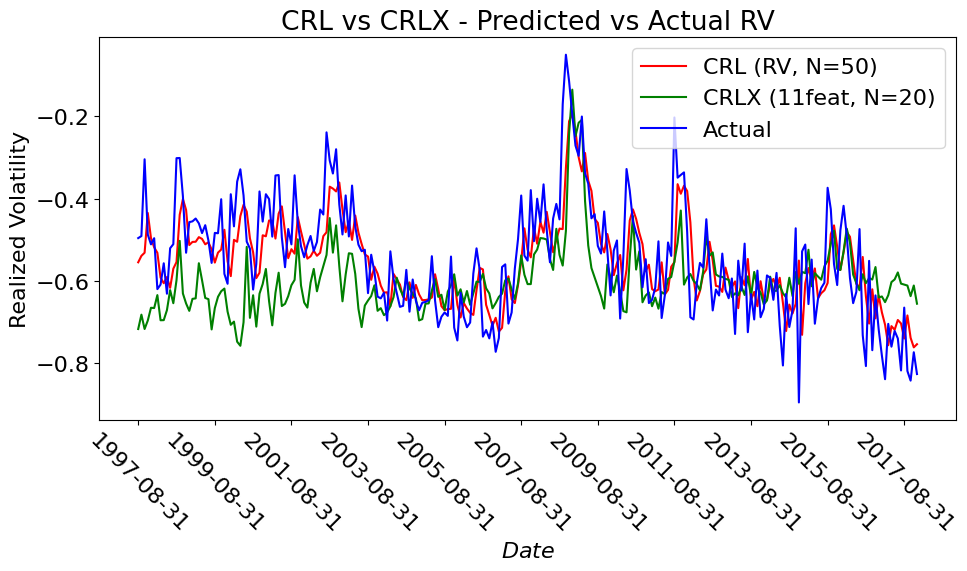

In [40]:
# =============================================================================
# Comparison Plot: CRL vs CRLX vs Actual RV
# =============================================================================
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.title("CRL vs CRLX - Predicted vs Actual RV")
plt.xlabel("$Date$")
plt.plot(test.index, predictions_crl, label=f"CRL (RV, N={best_N_crl})", color="red")
plt.plot(test.index, predictions_crlx, label=f"CRLX (11feat, N={best_N_crlx})", color="green")
plt.plot(test.index, RV[WL:], label="Actual", color="blue")
plt.xticks(test.index[::24], rotation=-45)
plt.ylabel('Realized Volatility')
plt.tight_layout()
plt.legend()
plt.savefig("Classical_Reservoir_learning/crl_comparison.png")
plt.show()


In [41]:
# =============================================================================
# QLIKE Loss Functions (same as LSTM.ipynb — see that notebook for details)
# =============================================================================
def compute_qlike(forecasts, actuals):
    """Sum-based QLIKE loss. See LSTM.ipynb cell 14 for full documentation."""
    forecasts = np.abs(forecasts)
    actuals = np.abs(actuals)
    ratio = actuals / forecasts
    qlike = np.sum(ratio - np.log(ratio) - 1)
    return qlike


def qlike_loss(y_true, y_hat):
    """Mean-based alternative QLIKE loss (not used in final MCS comparison)."""
    eps = np.finfo(float).eps
    w = np.abs(y_true - y_hat) / (y_hat + eps)
    return np.mean(np.log(1 + w**2))


In [42]:
# =============================================================================
# Print MSE metrics for both reservoir variants
# =============================================================================
actual = RV[WL:]  # True RV for the 245-month test period

print(f"--- CRL (base, RV-only, best N={best_N_crl}) ---")
mse1 = np.mean((predictions_crl - actual) ** 2)
print(f"  MSE: {mse1:.6f}")

print(f"\n--- CRLX (extended, 11 features, best N={best_N_crlx}) ---")
mse2 = np.mean((predictions_crlx - actual) ** 2)
print(f"  MSE: {mse2:.6f}")


--- CRL (base, RV-only, best N=50) ---
  MSE: 0.009524

--- CRLX (extended, 11 features, best N=20) ---
  MSE: 0.019638
